# Criação de Mapa com tags

https://getbootstrap.com/docs/3.3/components/

https://fontawesome.com/v4/icons/

In [ ]:
import pandas as pd
import requests
import folium
from folium.plugins import HeatMap
from folium.plugins import Geocoder # para barra de pesquisa
from branca.element import Element # para legenda
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [ ]:
df = pd.read_csv('final_places.csv')

In [ ]:
categories_config = {
    'nightclub/bar': {'color': 'pink', 'icon':'glyphicon glyphicon-glass' , 'prefix': 'glyphicon'},
    'sauna': {'color':'darkred', 'icon':'fa-bath', 'prefix': 'fa'},
    'restaurant': {'color':'orange', 'icon':'glyphicon glyphicon-cutlery' , 'prefix': 'glyphicon'},
    'association': {'color':'purple', 'icon':'glyphicon glyphicon-heart-empty' , 'prefix': 'glyphicon'},
    'accommodation': {'color':'green', 'icon':'fa-bed', 'prefix': 'fa'},
    'cultural space': {'color':'gray', 'icon':'film' , 'prefix': 'glyphicon'},
    'store': {'color':'lightblue', 'icon':'glyphicon glyphicon-shopping-cart' , 'prefix': 'glyphicon'}, #or glyphicon glyphicon-tag
    }

In [ ]:
subtitle_html = """
<div style="
    position: fixed;
    bottom: 20px;
    right: 20px;
    z-index: 1000;
    background: white;
    padding: 10px;
    border: 1px solid gray;
    opacity: 0.9;
    font-family: Arial;
    max-height: 200px;
    overflow-y: auto;
">
    <b>Subtitle</b>
"""
for name, config in categories_config.items():
    subtitle_html += f"""
    <div style="margin: 5px 0;">
        <span style="color: {config['color']}; font-size: 18px;">■</span>
        {name}
    </div>
    """

subtitle_html += "</div>"

subtitle = Element(subtitle_html)

In [ ]:
default_color = 'black'
center = [38.7223, -9.1393]
lisbon_map = folium.Map(location=center, zoom_start=14)
lisbon_map.get_root().html.add_child(subtitle)

Geocoder().add_to(lisbon_map)

for i, row in df.iterrows():
    if pd.notna(row['latitude']) and pd.notna(row['longitude']):
        coordinates = [row['latitude'], row['longitude']]
        name = row['name']
        address = row['completed_address']
        category = row['category']
        site = row['website']

        icon_config = categories_config.get(category, {
                                             'color': default_color,
                                             'icon': 'glyphicon glyphicon-remove',
                                             'prefix': 'glyphicon'
                                            })
        html_popup = f"""
        <h4>{name}</h4>
        <p>
        <b>Address: </b> {address}<br>
        </p>
        <p>
        <b>Category: </b> {category}<br>
        </p>
        <p>
        <b>Site: </b> {site}<br>
        </p>
        """
        popup = folium.Popup(html_popup, max_width=250)
        folium.Marker(
            location=coordinates,
            popup=popup,
            tooltip=name,
            icon=folium.Icon(
                icon = icon_config['icon'],
                color= icon_config['color'],
                prefix= icon_config['prefix'],
                icon_color='white'
                ) ).add_to(lisbon_map)

lisbon_map.save('lisbon_places_map.html')
lisbon_map

## Criação de um HeatMap

In [ ]:
data = df[['latitude', 'longitude']].copy()
data.dropna(inplace=True)

lisbon_map_heatmap = folium.Map(location=center, zoom_start=13)

if not data.empty:
    HeatMap(
        data = data,
        radius=15,
        blur=10
    ).add_to(lisbon_map_heatmap)
else:
    print("erro")

# 4. Salve o mapa de calor em um arquivo HTML diferente
lisbon_map_heatmap.save('lisbon_places_heatmap.html')
lisbon_map_heatmap

In [ ]:
# Contagem de locais por categoria
contagem_categorias = df['category'].value_counts()
contagem_categorias

category
nightclub/bar     26
accommodation      8
restaurant         7
sauna              3
cultural space     3
association        3
store              2
Name: count, dtype: int64

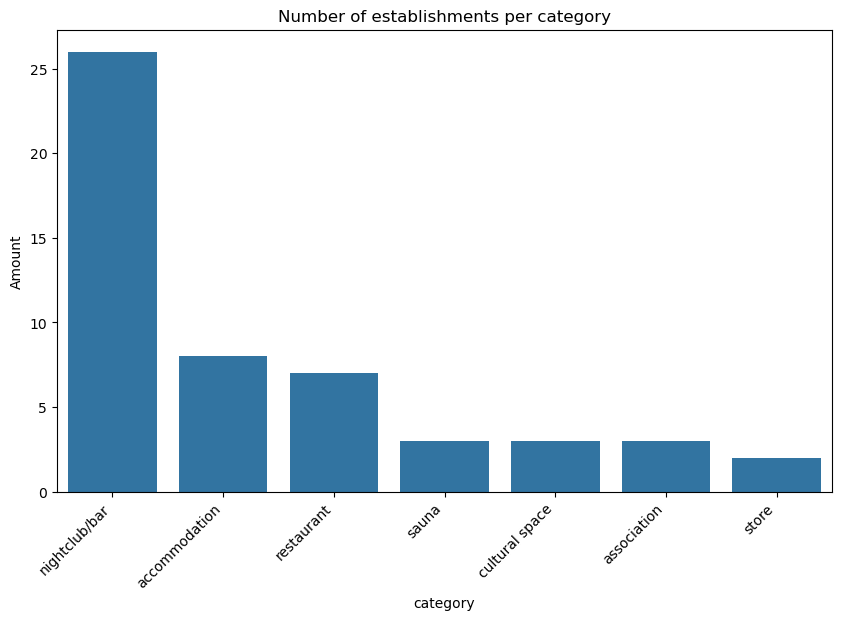

In [ ]:
# Plotar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=contagem_categorias.index, y=contagem_categorias.values)
plt.title('Number of establishments per category')
plt.ylabel('Amount')
plt.xticks(rotation=45, ha='right')
plt.savefig('number_per_category.png', dpi=300, bbox_inches='tight')
plt.show()

## Mapa Freguesias

https://dados.cm-lisboa.pt/dataset/freguesias-2012 -> infos de freguesias de Lisboa

In [ ]:
url_freguesias = 'https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/Limite_Cartografia/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson'

freguesias_map = folium.Map(location=[38.7223, -9.1393],tiles = "CartoDB positron", zoom_start=12)

style = lambda x: {
    "fillColor": "white",
    "color": "black",
    "fillOpacity": 0.1,
    "weight": 1
}

highlight_style = lambda x: {
    "fillColor": "blue",
    "color": "black",
    "fillOpacity": 0.5,
    "weight": 1
}

highlight = folium.features.GeoJson(
    data=url_freguesias,
    style_function=style,
    highlight_function=highlight_style,
    name="Freguesias de Lisboa"
)

folium.features.GeoJsonTooltip(
    fields=["NOME"],
    aliases=["Freguesia:"],
    fill_color = "GnBu",
    fill_opacity = 0.9,
    line_opacity = 0.5,
    nan_fill_color = "white",
    labels=True,
    sticky=True,
    style=("background-color: white; color: black; font-family: arial; font-size: 16px; padding: 10px;")
).add_to(highlight)

freguesias_map.add_child(highlight)
folium.LayerControl().add_to(freguesias_map)
freguesias_map.save('freguesias_map.html')

freguesias_map

Infos sobre estabelecimentos de Lisboa:
https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/POICultura/FeatureServer/2/query?where=1%3D1&outFields=*&f=pgeojson cinema

https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/POILazer/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson cassino

https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/Desporto_CentrosDesportivos/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson centros esportivos

https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/POIComprar/FeatureServer/0/query?where=1%3D1&outFields=*&f=pgeojson comerciais

https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/POICultura/FeatureServer/7/query?where=1%3D1&outFields=*&f=pgeojson culturais


Tem empresas municipais, centros de saúde...

https://censos.ine.pt/xportal/xmain?xpgid=censos21_populacao&xpid=CENSOS21 censo 2021



https://tabulador.ine.pt/indicador/?id=0011609 -> AQUI
https://tabulador.ine.pt/indicador/?id=0011678

https://tabulador.ine.pt/CENSOS2021/

In [ ]:
gdf_freguesias = gpd.read_file(url_freguesias)
gdf_from_df = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude)
)
df_freguesia = gpd.sjoin(gdf_from_df, gdf_freguesias, how="inner", predicate='within')
df_freguesia = df_freguesia.drop('freguesia', axis=1)
df_freguesia.rename(columns={'NOME': 'freguesia'}, inplace=True)
df_freguesia



C:\Users\izzy\AppData\Local\Temp\ipykernel_19864\3145974726.py:6: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  df_freguesia = gpd.sjoin(gdf_from_df, gdf_freguesias, how="inner", predicate='within')


,name,category,geolocated_address,ref,website,latitude,longitude,completed_address,point,geometry,...,OBJECTID,COD_SIG,freguesia,IDTIPO,PERIMETRO,AREA_M2,FREGUESIAS53,GlobalID,Shape__Area,Shape__Length
0,TRUMPS,nightclub/bar,"Trumps Lisbon, 104B, Rua da Imprensa Nacional,...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://trumps.pt/shop/,38.717415,-9.151900,"Trumps Lisbon, 104B, Rua da Imprensa Nacional,...","(38.7174149, -9.1519004, 0.0)",POINT (-9.1519 38.71741),...,9,122,Santo António,4015,6313.89,1494328.42,Coração de Jesus + São José + São Mamede,e7929593-0609-44a2-95d5-32962d333a90,2.458059e+06,8097.072849
1,SOCIETY,nightclub/bar,"Rua Cecílio de Sousa, 72, Mercês, Santo Antóni...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://www.instagram.com/societylisboa/?hl=en,38.716060,-9.150158,"Rua Cecílio de Sousa, Mercês, Santo António, M...","(38.7160598, -9.1501583, 0.0)",POINT (-9.15016 38.71606),...,9,122,Santo António,4015,6313.89,1494328.42,Coração de Jesus + São José + São Mamede,e7929593-0609-44a2-95d5-32962d333a90,2.458059e+06,8097.072849
2,FRIENDS,nightclub/bar,"Travessa da Água-da-Flor, 17, Bairro Alto, Mis...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://www.instagram.com/friendsbairroalto/?h...,38.713584,-9.144654,"Travessa da Água-da-Flor, Bairro Alto, Miseric...","(38.7135842, -9.1446535, 0.0)",POINT (-9.14465 38.71358),...,2,116,Misericórdia,4015,7419.68,2192169.25,Encarnação + Mercês + Santa Catarina + São Paulo,85c29313-bc22-4596-8535-9f68940f23f4,3.604372e+06,9520.381626
3,POSH CLUB,nightclub/bar,"157, Rua de São Bento, Amoreiras, Santa Isabel...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://www.poshclublisbon.com/,38.714759,-9.154028,"157, Rua de São Bento, Amoreiras, Santa Isabel...","(38.7147594, -9.1540276, 0.0)",POINT (-9.15403 38.71476),...,1,113,Estrela,4015,9927.85,4604033.92,Lapa + Prazeres + Santos-o-Velho,f118b5be-1005-43fb-9422-161c4e983434,7.569563e+06,12734.425242
4,CORVO,nightclub/bar,"Calçada Engenheiro Miguel Pais, 18, São Mamede...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,(fechou)https://www.instagram.com/corvo_princi...,38.717143,-9.151472,"Calçada Engenheiro Miguel Pais, São Mamede, Sa...","(38.7171429, -9.1514721, 0.0)",POINT (-9.15147 38.71714),...,9,122,Santo António,4015,6313.89,1494328.42,Coração de Jesus + São José + São Mamede,e7929593-0609-44a2-95d5-32962d333a90,2.458059e+06,8097.072849
5,BAR CRU,nightclub/bar,"Bar Cru, 170, Rua de São Marçal, Mercês, Santo...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://thebarcru.com/,38.715988,-9.150327,"Bar Cru, 170, Rua de São Marçal, Mercês, Santo...","(38.7159879, -9.1503266, 0.0)",POINT (-9.15033 38.71599),...,9,122,Santo António,4015,6313.89,1494328.42,Coração de Jesus + São José + São Mamede,e7929593-0609-44a2-95d5-32962d333a90,2.458059e+06,8097.072849
6,MARIA LISBOA,nightclub/bar,"Rua da Atalaia, 97, Bairro Alto, Misericórdia,...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://www.facebook.com/MariaLisboaClub/,38.712770,-9.145033,"Rua da Atalaia, Bairro Alto, Misericórdia, Lis...","(38.7127697, -9.1450332, 0.0)",POINT (-9.14503 38.71277),...,2,116,Misericórdia,4015,7419.68,2192169.25,Encarnação + Mercês + Santa Catarina + São Paulo,85c29313-bc22-4596-8535-9f68940f23f4,3.604372e+06,9520.381626
7,VLADA LOUNGE,nightclub/bar,"8, Rua Rosa Damasceno, Arroios, Lisboa, 1900-9...",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://www.instagram.com/vladalounge/?hl=en,38.735957,-9.131970,"8, Rua Rosa Damasceno, Arroios, Lisboa, 1900-9...","(38.7359566, -9.1319704, 0.0)",POINT (-9.13197 38.73596),...,10,105,Arroios,4015,8240.33,2127843.26,Anjos + Pena + São Jorge de Arroios,ca01a95d-5cbf-4e81-831c-8f1486c8a5e6,3.500772e+06,10572.543846
8,CONSTRUCTION,nightclub/bar,"RUA CECILIO DE SOUSA, 82, Lisboa, Portugal",https://www.timeout.pt/lisboa/pt/noite/os-melh...,https://www.instagram.com/construction_bar/?hl=en,38.716060,-9.150158,"Rua Cecílio de Sousa, Mercês, Sant

In [ ]:
contagem_por_freguesia = df_freguesia['freguesia'].value_counts()
contagem_por_freguesia

freguesia
Misericórdia         25
Santo António        13
Santa Maria Maior     5
Arroios               3
Estrela               1
Alcântara             1
Campo de Ourique      1
São Vicente           1
Lumiar                1
Name: count, dtype: int64

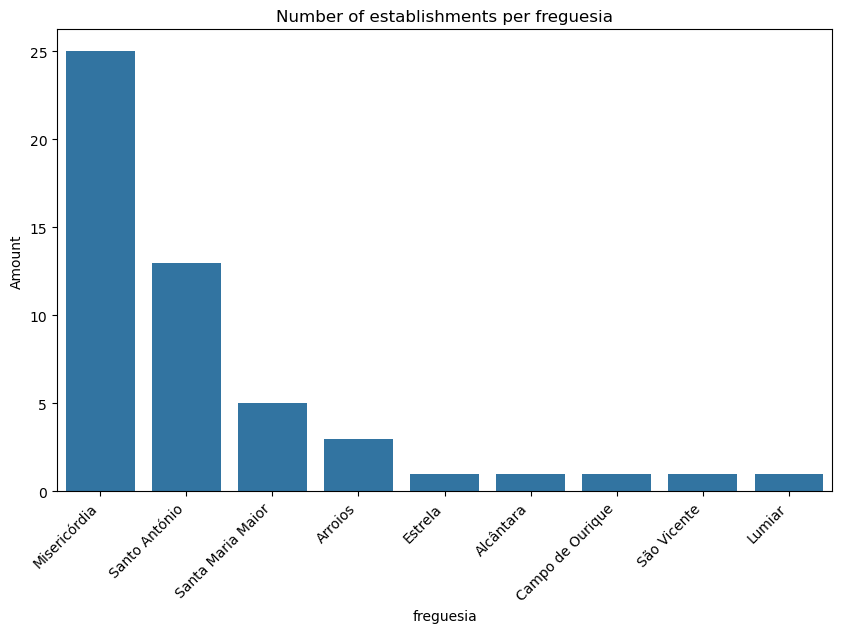

In [ ]:
# Plotar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=contagem_por_freguesia.index, y=contagem_por_freguesia.values)
plt.title('Number of establishments per freguesia')
plt.ylabel('Amount')
plt.xticks(rotation=45, ha='right')
plt.savefig('number_per_freguesia.png', dpi=300, bbox_inches='tight')
plt.show()

https://www.cortex-intelligence.com/blog/geomarketing-identifique-o-potencial-de-uma-regiao-ou-ponto-comercial

In [ ]:
df_pop = pd.read_csv("pop_renda.csv")
df_pop.head()

,cod,location,pop_total,pop_under_20,pop_20,pop_50,pop_75,pop_100,pop_150,pop_200,pop_300,pop_400,pop_500,pop_650,pop_over_1000
0,11,Portugal,2 190 629,88 803,105 773,77 614,58 649,120 845,151 489,427 539,454 027,275 328,220 010,150 962,59 590
1,1106,Lisboa,226 683,11 907,14 717,10 552,8 161,13 228,10 896,18 897,20 454,19 233,28 195,43 984,26 459
2,110601,Ajuda,7 012,548,925,428,269,458,348,625,728,777,889,829,188
3,110602,Alcântara,7 089,116,284,271,193,375,395,684,775,846,1 210,1 464,476
4,110654,Alvalade,12 284,297,325,319,220,439,409,623,764,760,1 666,3 923,2 539


In [ ]:
df_pop_limpo = df_pop.rename(columns={'location':'freguesia'})

df_merge = pd.merge(
    left=contagem_por_freguesia,
    right=df_pop_limpo,
    on='freguesia',
    how='inner'
)
df_merge

,freguesia,count,cod,pop_total,pop_under_20,pop_20,pop_50,pop_75,pop_100,pop_150,pop_200,pop_300,pop_400,pop_500,pop_650,pop_over_1000
0,Misericórdia,25,110661,5 532,84,143,201,175,350,277,532,633,623,829,1 100,585
1,Santo António,13,110666,5 172,45,64,74,80,231,177,361,370,375,764,1 282,1 349
2,Santa Maria Maior,5,110665,6 871,184,260,233,229,386,365,655,946,892,1 179,1 117,425
3,Arroios,3,110656,17 099,102,157,228,233,596,539,1 215,1 808,1 824,2 928,4 945,2 524
4,Estrela,1,110660,9 427,163,241,247,228,400,361,555,742,847,1 352,2 111,2 180
5,Alcântara,1,110602,7 089,116,284,271,193,375,395,684,775,846,1 210,1 464,476
6,Campo de Ourique,1,110659,11 257,275,380,364,295,572,547,935,1 107,1 115,1 455,2 501,1 711
7,São Vicente,1,110667,8 257,202,243,206,213,453,389,756,1 053,1 166,1 593,1 544,439
8,Lumiar,1,110618,11 520,711,840,734,533,758,518,661,765,664,986,2 618,1 732


In [ ]:
df_merge['pop_total'] = df_merge['pop_total'].str.replace(' ', '', regex=False)
df_merge['count'] = df_merge['count'].astype(str).str.replace(' ', '', regex=False)

df_merge['pop_total'] = pd.to_numeric(df_merge['pop_total'], errors='coerce')
df_merge['count'] = pd.to_numeric(df_merge['count'], errors='coerce')

In [ ]:
corr = df_merge['count'].corr(df_merge['pop_total'])
print(f"\nO coeficiente de correlação entre a contagem de Locais e populaçao é: {corr:.4f}")


O coeficiente de correlação entre a contagem de Locais e populaçao é: -0.5142
